In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

import lsstypes as types

from clustering_statistics import tools

In [3]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

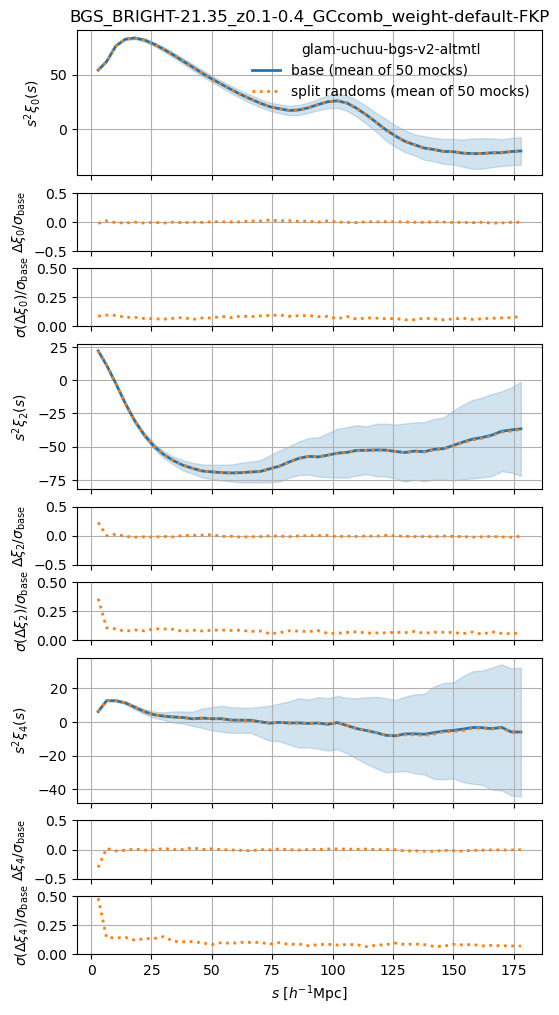

In [4]:
lw=2

imocks = 150 + np.arange(50)
base = Path('/pscratch/sd/a/arosado/cai-dr2-benchmarks/full_shape/base/glam-uchuu-bgs-v2-altmtl/')
stats_split = [types.read(base / f'mock{imock}/particle2_correlation_smu_BGS_BRIGHT-21.35_z0.1-0.4_GCcomb_weight-default-FKP.h5').project(ells=[0,2,4]).select(s=slice(0, None, 4)) for imock in imocks] 
mean_split = types.mean(stats_split)
cov_split  = types.cov(stats_split).at.observable.match(mean_split)

base = tools.base_stats_dir / 'full_shape/base/glam-uchuu-bgs-v2-altmtl/'
stats = [types.read(base / f'mock{imock}/particle2_correlation_smu_BGS_BRIGHT-21.35_z0.1-0.4_GCcomb_weight-default-FKP.h5').project(ells=[0,2,4]).select(s=slice(0, None, 4)) for imock in imocks] 
mean = types.mean(stats)
cov  = types.cov(stats).at.observable.match(mean)

ells = mean.ells
ylim=(-.5, .5)
nrows  = len(ells) * 3
ncols  = 1
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1, 1] * len(ells)})
if axes.ndim == 1:
    lax = axes
else:
    lax = axes[:, ax_col]

kexp = 2
for ill, ell in enumerate(ells):
    ax = lax[3 * ill]
    ax.set_ylabel(rf'$s^2 \xi_{ell:d}(s)$')

    pole = mean.get(ell)
    k = pole.coords('s')
    value = k**kexp * pole.value()
    ax.plot(k,value,color="C0",ls='-',label=f"base (mean of {len(stats)} mocks)", lw=lw)

    std = k**kexp * cov.at.observable.get(ell).std().real
    ax.fill_between(k, value - std, value + std, color="C0", alpha=0.2)
    
    pole = mean_split.get(ell)
    k = pole.coords('s')
    value = k**kexp * pole.value()
    ax.plot(k,value,color="C1",ls=':',label=f"split randoms (mean of {len(stats)} mocks)", lw=lw)

    if ill == 0: ax.legend(frameon=False,title='glam-uchuu-bgs-v2-altmtl')
    ax.grid(True)
    ax = lax[3 * ill + 1]
    ax.set_ylabel(rf'$\Delta \xi_{ell:d} / \sigma_\mathrm{{base}}$')
    ax.grid(True)
    ax.set_ylim(*ylim)

    pole = mean_split.get(ell)
    k = pole.coords('s')
    std = cov.at.observable.get(ell).std()
    ax.plot(k, (pole.value() - mean.get(ell).value()) / std, color="C1", ls=':', lw=lw)

    ax = lax[3 * ill + 2]
    ax.set_ylabel(rf'$\sigma(\Delta \xi_{ell:d}) / \sigma_\mathrm{{base}}$')
    ax.grid(True)
    ax.set_ylim(0,0.5)
    
    # This assumes that each element of stats corresponds to the same mock realization.
    diff = [stats[imock].get(ell).value() - stats_split[imock].get(ell).value() for imock in range(len(stats))]
    std_diff = np.std(diff, axis=0)
    std = cov.at.observable.get(ell).std() 
    ax.plot(k, std_diff / std, color="C1", ls=':', lw=lw)
    
    
lax[-1].set_xlabel(r'$s$ [$h^{-1}\mathrm{Mpc}$]')
lax[0].set_title('BGS_BRIGHT-21.35_z0.1-0.4_GCcomb_weight-default-FKP')
plt.savefig(plot_dir / f'validation_split_randoms.{ext}',bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()